# Exploring Sentinel-2 with Google Earth Engine

**Goal:** authenticate to Earth Engine, pull cloud-masked Sentinel-2 imagery over the Riau study area, build one clean composite, and look at it.

This notebook is for *learning and exploration*. Once I've confirmed the parameters look good, I'll harden the key functions into `src/landcover/gee.py` for the real pipeline.

> **Note:** render imagery as **static thumbnails** (Earth Engine's `getThumbURL`) rather than an interactive `geemap` map. On Colab the interactive map needs a Google Maps API key in secrets; thumbnails need nothing and always work, and `getThumbURL` is exactly how I'll export figures later.

## 0. Install (Colab only)

`earthengine-api` is all that's needed to talk to GEE and pull thumbnails.

In [29]:
!pip install -q earthengine-api

## 1. Authenticate & initialize

`ee.Authenticate()` opens a browser flow (on Colab it's a click-through). Only done once per environment. `ee.Initialize` ties the session to the Cloud project, **landcover-riau**.

I also define a tiny `show()` helper that turns any Earth Engine image into a PNG and displays it inline.

In [30]:
import ee
from IPython.display import Image as IPyImage, display

PROJECT = "landcover-riau"

ee.Authenticate()
ee.Initialize(project=PROJECT)
print("Earth Engine ready, project:", PROJECT)


def show(image, vis, region, dims=600, label=None):
    """Render an ee.Image as a static thumbnail PNG and display it inline.

    `vis` is a dict like {'bands': [...], 'min': .., 'max': ..} or a palette.
    `region` is the ee.Geometry to clip the thumbnail to.
    """
    params = dict(vis)
    params["region"] = region
    params["dimensions"] = dims
    url = image.getThumbURL(params)
    if label:
        print(label)
    display(IPyImage(url=url))

Earth Engine ready, project: landcover-riau


## 2. Define the study area (AOI)

A ~55 x 55 km box over the Kampar / Pelalawan lowlands in Riau, Sumatra, whcih is a hard-hit oil-palm deforestation front. Bounds are `[W, S, E, N]` in lon/lat. These mirror `configs/config.py`; I'll retune them after I see the imagery.

In [31]:
AOI_BBOX = [101.5, 0.0, 102.0, 0.5]   # W, S, E, N
aoi = ee.Geometry.Rectangle(AOI_BBOX)

# Sanity check: how big is the area?
area_km2 = aoi.area().getInfo() / 1e6
print(f"AOI area: {area_km2:,.0f} km^2  (bounds {AOI_BBOX})")

AOI area: 3,091 km^2  (bounds [101.5, 0.0, 102.0, 0.5])


## 3. Load a Sentinel-2 ImageCollection

I use **surface reflectance, harmonized** (`COPERNICUS/S2_SR_HARMONIZED`). Filtering by area and date narrows the global archive to just the scenes I need.

> **Data availability:** I explore with 2024 here, but the project's snapshots are **2019 / 2021 / 2024**. Sentinel-2 atmospherically-corrected surface reflectance only has systematic coverage over Indonesia from around 2019.

In [32]:
YEAR = 2024
START = f"{YEAR}-06-01"   # dry season in central Sumatra: fewer clouds
END   = f"{YEAR}-09-30"

s2_raw = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi)
    .filterDate(START, END)
)

print("Scenes over AOI in window:", s2_raw.size().getInfo())

Scenes over AOI in window: 197


## 4. Cloud masking with Cloud Score+

Tropical scenes are mostly cloud, so a single image is useless. **Cloud Score+** is Google's modern per-pixel quality score (0 = bad/cloud, 1 = clear). I attach it to each scene with `linkCollection`, then mask out pixels below a clear-threshold.

> A higher `CLEAR_THRESHOLD` gives a cleaner, sharper composite but masks more pixels (risking gaps where nothing is clear enough). `0.6` balances cleanliness vs coverage for the usually cloudy Riau.

In [33]:
QA_BAND = "cs_cdf"          # Cloud Score+ band (cumulative distribution variant)
CLEAR_THRESHOLD = 0.6       # keep pixels at least this 'clear'

cs_plus = ee.ImageCollection("GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED")

s2_masked = (
    s2_raw
    .linkCollection(cs_plus, [QA_BAND])
    .map(lambda img: img.updateMask(img.select(QA_BAND).gte(CLEAR_THRESHOLD)))
)

## 5. Composite: reduce the stack to one clean image

For each pixel, take the **median** across all (masked) scenes in the window. Clouds were masked out, so the median lands on a clear, representative value. This is the analysis-ready image for the year.

In [34]:
composite = s2_masked.median().clip(aoi)

# True-colour view. S2 SR reflectance is scaled by 10000.
rgb_vis = {"bands": ["B4", "B3", "B2"], "min": 0, "max": 3000}

show(composite, rgb_vis, region=aoi, label=f"Sentinel-2 true colour, {YEAR}")

Sentinel-2 true colour, 2024


## 6. False colour + NDVI

**False colour** (NIR-Red-Green = `B8,B4,B3`) makes living vegetation glow red, because healthy plants reflect strongly in the near-infrared.

**NDVI** = (NIR − Red)/(NIR + Red) collapses that into one number per pixel: high (~0.8) = dense forest, low/negative = water or bare ground. This single index is most of how I'll tell forest from cleared land.

In [35]:
false_color = {"bands": ["B8", "B4", "B3"], "min": 0, "max": 3000}

ndvi = composite.normalizedDifference(["B8", "B4"]).rename("NDVI")
ndvi_vis = {"min": -0.2, "max": 0.9,
            "palette": ["#b35806", "#f7f7f7", "#1b7837"]}  # bare -> grey -> forest

show(composite, false_color, region=aoi, label="False colour (vegetation = red)")
show(ndvi, ndvi_vis, region=aoi, label="NDVI (green = dense forest)")

False colour (vegetation = red)


NDVI (green = dense forest)


## 7. Water index (NDWI)

**NDWI** = (Green − NIR)/(Green + NIR) is the mirror of NDVI for water: water reflects green and absorbs NIR, so it scores high while vegetation and soil score low. This is a quick way to isolate the 'water' class.

In [36]:
# NDWI = (Green - NIR) / (Green + NIR). Water reflects green, absorbs NIR,
# so water pixels score HIGH while vegetation/soil score low or negative.

ndwi = composite.normalizedDifference(["B3", "B8"]).rename("NDWI")
ndwi_vis = {"min": -0.5, "max": 0.5,
            "palette": ["#ffffcc", "#a1dab4", "#2c7fb8", "#253494"]}  # dry → water
show(ndwi, ndwi_vis, region=aoi, label="NDWI (dark blue = water)")

NDWI (dark blue = water)


The Kampar river shows as a sharp blue ribbon while vegetation and soil sit near-white at low NDWI (the inverse of where NDVI was lowest). Water is highly separable, so the 'water' class should be the easiest for the model to predict.

## 8. NDVI distribution & why a single threshold isn't enough

Sampling NDVI across the AOI and plotting the histogram shows how separable the classes are by index alone.

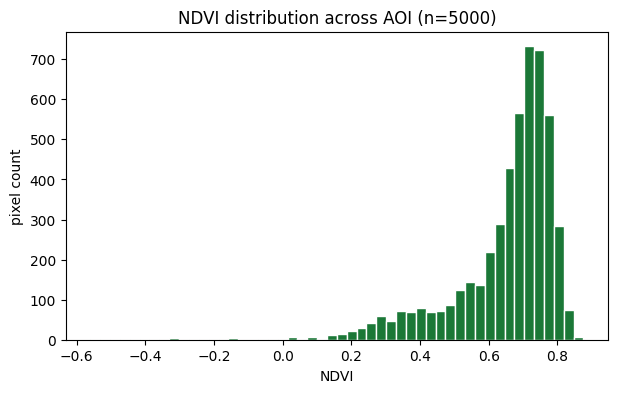

min=-0.56  max=0.88


In [37]:
import matplotlib.pyplot as plt

# Pull a random sample of NDVI values back to the client to plot.
# sample as cant plot millions of points

samples = (ndvi
           .sample(region=aoi, scale=30, numPixels=5000, geometries=False)
           .aggregate_array("NDVI")
           .getInfo())

plt.figure(figsize=(7, 4))
plt.hist(samples, bins=50, color="#1b7837", edgecolor="white")
plt.xlabel("NDVI"); plt.ylabel("pixel count")
plt.title(f"NDVI distribution across AOI (n={len(samples)})")
plt.show()

print(f"min={min(samples):.2f}  max={max(samples):.2f}")

NDVI is high and **left-skewed**, mass piled around 0.8–0.9 with a thin tail to low values (min ≈ −0.58 = water, max ≈ 0.91 = dense canopy). The AOI is overwhelmingly vegetated, and crucially **both intact forest and oil-palm plantation score high NDVI**, so the histogram is *not* cleanly bimodal. A simple NDVI threshold can't separate forest from plantation. Distinguishing them needs the full multispectral signal (especially SWIR B11/B12) plus spatial texture, i.e. a segmentation model. This plot is the core justification for the U-Net over naive index thresholding.